In [1]:
import sys
import importlib
# 削除された 'imp' モジュールを 'importlib' で代用するパッチ
sys.modules['imp'] = importlib

# （もしこの後に warnings が出たら無視して進めて大丈夫です）

In [2]:
# Google DriveをColabに接続する
from google.colab import drive
drive.mount('/content/drive')

# プロジェクトのルートフォルダ（mast-cell-project）に移動する
import os
# ※ 'mast-cell-project' の部分はご自身がDriveで作ったフォルダ名に合わせてください
os.chdir('/content/drive/MyDrive/mast-cell-project')

# 現在の場所を確認（/content/drive/MyDrive/mast-cell-project と出れば成功！）
!pwd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/mast-cell-project


In [3]:
!pip install mygene boruta pecanpy biopython transformers

タイトルと概要

# 🧬 マスト細胞 脱顆粒因子の探索パイプライン (マルチモーダルAI解析)

本ノートブックでは、トランスクリプトーム(GEO)、タンパク質機能(UniProt)、言語モデル(ESM-2)、ネットワーク(STRING)を統合し、マスト細胞の脱顆粒に関与する新規ターゲット遺伝子を予測します。

**解析ステップ:**
1. **データロード:** GEO発現データと既知の正例・負例の読み込み
2. **特徴量抽出:** 配列、テキスト、ネットワーク、ドメイン情報の統合
3. **特徴量選択:** Borutaによる統計的に有意なバイオマーカーの厳選
4. **学習と評価:** Stratified 5-Fold CVによる安定性の検証
5. **新規候補の予測:** 未知の遺伝子に対するスコアリング

環境設定とインポート

In [4]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 自作モジュール（srcディレクトリ）からのインポート
from src.data_loader import get_target_genes, load_geo_data, fetch_uniprot_features
from src.features import extract_esm2_features, extract_tfidf_features, get_string_interaction, generate_graph_embeddings
from src.models import run_boruta_selection, train_and_evaluate_cv, plot_feature_importance_stability, predict_novel_targets

# グラフの見た目を綺麗にする設定
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Step 1: データの読み込みと正例・負例の定義
GEO (GSE75526) の発現データから、Tauスコア（発現特異性）やFold Changeを計算します。
また、既知の脱顆粒関連遺伝子（Positive）と、特徴が似ているが関与しない遺伝子（Hard Negative）を定義します。

In [6]:
# 1. ターゲット遺伝子の取得
positives, negatives = get_target_genes()
target_genes = positives + negatives

# 2. GEOデータの読み込み（キャッシュがあれば一瞬で終わります）
df_geo = load_geo_data(raw_file_path="/content/drive/MyDrive/mast-cell-project/data/raw/GSE75526_fpkm.txt.gz",
                       cache_path="/content/drive/MyDrive/mast-cell-project/data/processed/GSE75526_processed.pkl")

print(f"Total GEO genes: {len(df_geo)}")
print(f"Target genes (Positives: {len(positives)}, Negatives: {len(negatives)})")

Processing raw GEO data...


Calculating p_values: 100%|██████████| 23951/23951 [00:47<00:00, 508.62it/s]


Total GEO genes: 17019
Target genes (Positives: 38, Negatives: 47)


## Step 2: マルチモーダル特徴量の抽出
各遺伝子に対し、以下の4つのモダリティから特徴量を抽出・統合します。
* **Transcriptome:** GEOからの発現特異性 (Tau Score)
* **Annotation & NLP:** UniProtドメイン情報とキーワードのTF-IDFベクトル
* **Sequence:** ESM-2 (タンパク質言語モデル) による配列埋め込み
* **Network:** STRINGデータベースとNode2vecによるグラフ埋め込み

In [9]:
import os
import pandas as pd

# 特徴量を結合した最終データの保存先
features_cache_path = "/content/drive/MyDrive/mast-cell-project/data/processed/all_features_integrated.pkl"

# === 1. 解析対象とする全遺伝子のリストを作成 ===
# GEOデータで発現が確認された全遺伝子を対象にする（T4 GPUを使用するため全件処理）
all_targets = df_geo['Gene_ID'].tolist()

# 念のため、学習に使う正例と負例が必ずネットワークに含まれるように結合・重複削除
all_targets = list(set(all_targets + positives + negatives))

print(f"解析対象の全遺伝子数: {len(all_targets)}")

if os.path.exists(features_cache_path):
    print("キャッシュされた全遺伝子の特徴量データを読み込みます...")
    df_main_all = pd.read_pickle(features_cache_path)
else:
    print("初回実行: 全遺伝子の特徴量抽出を一括で開始します（Colab T4 GPU環境）...")

    print("1. UniProtからアノテーションを取得中...")
    df_uniprot = fetch_uniprot_features(all_targets)

    print("2. ESM-2で全配列のベクトルを抽出中 (GPUをフル活用します)...")
    df_esm2, _ = extract_esm2_features(df_uniprot, n_components=10)
    df_esm2['Gene_ID'] = df_uniprot['Gene_ID'].values

    print("3. TF-IDFでテキスト特徴量を抽出中...")
    df_tfidf, _, _ = extract_tfidf_features(df_uniprot, n_components=10)
    df_tfidf['Gene_ID'] = df_uniprot['Gene_ID'].values

    print("4. STRINGネットワーク特徴量を抽出中 (巨大なネットワークを一括構築)...")
    # ※ raw/ までのフォルダパスを指定
    df_centrality, edge_df = get_string_interaction(
        all_targets,
        raw_data_dir="/content/drive/MyDrive/mast-cell-project/data/raw/"
    )

    print("5. Node2Vecでグラフ埋め込みを生成中...")
    df_graph = generate_graph_embeddings(edge_df, dimension=32)

    print("6. すべての特徴量を結合 (Merge)...")
    df_main_all = pd.DataFrame({'Gene_ID': all_targets})

    # 抽出した各特徴量を結合していく
    df_main_all = pd.merge(df_main_all, df_uniprot, on='Gene_ID', how='left')
    df_main_all = pd.merge(df_main_all, df_esm2, on='Gene_ID', how='left')
    df_main_all = pd.merge(df_main_all, df_tfidf, on='Gene_ID', how='left')
    df_main_all = pd.merge(df_main_all, df_centrality, on='Gene_ID', how='left')
    df_main_all = pd.merge(df_main_all, df_graph, on='Gene_ID', how='left')
    df_main_all = pd.merge(df_main_all, df_geo, on='Gene_ID', how='left')

    # ネットワーク外の遺伝子などの欠損値をゼロ埋め
    df_main_all = df_main_all.fillna(0)

    # 今後のために結果をキャッシュとして保存
    os.makedirs(os.path.dirname(features_cache_path), exist_ok=True)
    df_main_all.to_pickle(features_cache_path)
    print("全遺伝子の特徴量抽出と結合が完了し、保存されました！")

# === 2. 学習用データ (df_train) と 予測用データ (df_predict) の分割 ===
# 正例(1) または 負例(0) に該当する遺伝子だけを抽出して Label 列を作る
def assign_label(gene):
    if gene in positives: return 1
    if gene in negatives: return 0
    return None # 未知の遺伝子（これから予測するもの）

df_main_all['Label'] = df_main_all['Gene_ID'].apply(assign_label)

# 学習用データ（BorutaやRandomForestに渡す用）
df_train = df_main_all[df_main_all['Label'].notnull()].copy()
df_train['Label'] = df_train['Label'].astype(int)

# 予測用データ（未知のターゲット予測用）
df_predict = df_main_all[df_main_all['Label'].isnull()].copy()

print(f"学習用データ (df_train) のサイズ: {df_train.shape}")
print(f"未知の予測用データ (df_predict) のサイズ: {df_predict.shape}")

解析対象の全遺伝子数: 17025
初回実行: 全遺伝子の特徴量抽出を一括で開始します（Colab T4 GPU環境）...
1. UniProtからアノテーションを取得中...
Fetching data from UniProt for 17025 genes...


UniProt API: 100%|██████████| 171/171 [06:04<00:00,  2.13s/it]


2. ESM-2で全配列のベクトルを抽出中 (GPUをフル活用します)...


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting ESM2 Embeddings: 100%|██████████| 15783/15783 [1:09:06<00:00,  3.81it/s]


3. TF-IDFでテキスト特徴量を抽出中...
4. STRINGネットワーク特徴量を抽出中 (巨大なネットワークを一括構築)...
5. Node2Vecでグラフ埋め込みを生成中...
6. すべての特徴量を結合 (Merge)...
全遺伝子の特徴量抽出と結合が完了し、保存されました！
学習用データ (df_train) のサイズ: (83, 78)
未知の予測用データ (df_predict) のサイズ: (16942, 78)


## Step 3: Borutaによる特徴量選択 (Feature Selection)
高次元なマルチモーダルデータから、予測に統計的に有意に寄与する特徴量のみを厳密に選び出します。
過学習を防ぎ、モデルの解釈性を担保するための重要なプロセスです。

In [10]:
# 特徴量(X)とラベル(y)の分割 (※ df_train を使う)
X = df_train.drop(columns=['Gene_ID', 'Label', 'Sequence', 'Full_Text_Info'], errors='ignore')
y = df_train['Label']

# Borutaの実行
selected_features, boruta_selector = run_boruta_selection(X, y)
print(f"Selected Features: {selected_features}")

# 選択された特徴量のみにデータを絞り込む
X_selected = X[selected_features]

Starting Boruta feature selection with 74 features...
Boruta selected 15 features out of 74.
Selected Features: ['ESM2_PC_5', 'ESM2_PC_6', 'ESM2_PC_7', 'Text_SVD_3', 'Graph_Dim_13', 'Graph_Dim_17', 'Graph_Dim_18', 'Graph_Dim_19', 'Graph_Dim_20', 'Graph_Dim_23', 'Graph_Dim_24', 'Graph_Dim_25', 'Graph_Dim_27', 'ut_Expression', '-log10_p_value']


## Step 4: モデルの学習と安定性の評価
Random Forestを用いて分類モデルを構築します。
Stratified 5-Fold Cross Validationにより汎化性能を評価し、各Foldにおける特徴量重要度のブレ（安定性）を可視化します。

Starting Stratified 5-Fold Cross Validation...
--- CV Results ---
Accuracy     0.833088
Precision    0.914286
Recall       0.714286
F1           0.798462
AUC-ROC      0.906746
dtype: float64


,Mean CV Metrics
Fold,3.000000
Accuracy,0.833088
Precision,0.914286
Recall,0.714286
F1,0.798462
AUC-ROC,0.906746


/content/drive/MyDrive/mast-cell-project/src/models.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Importance', y='Feature', order=top_features, palette='viridis')


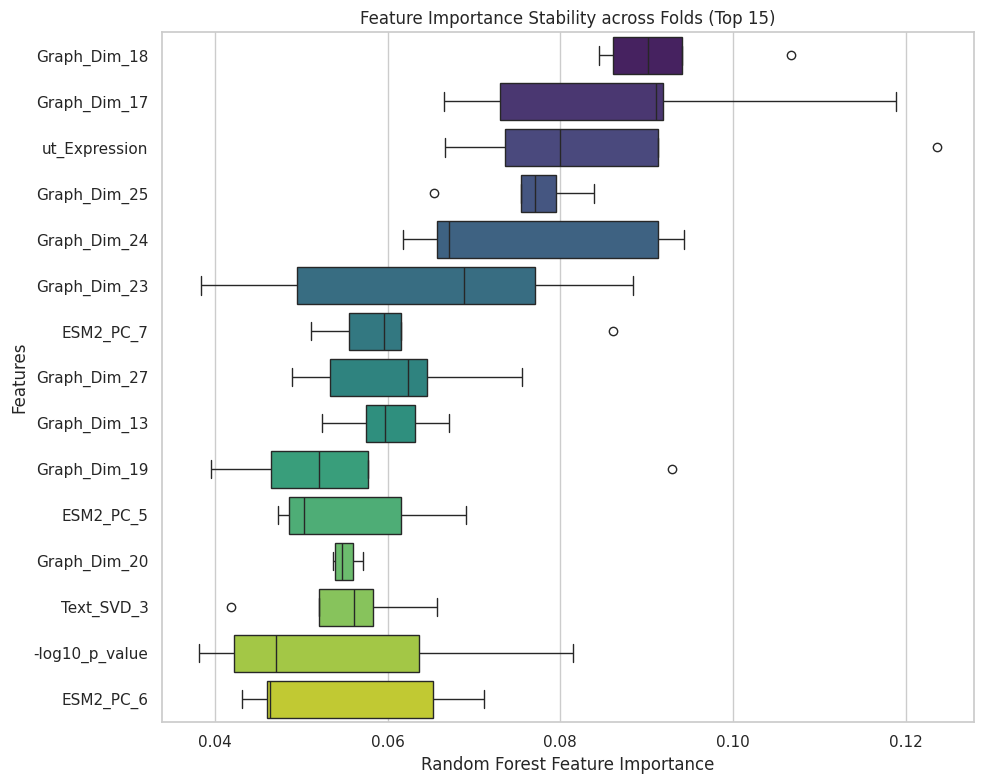

✅ 学習済みモデルと特徴量リストを /content/drive/MyDrive/mast-cell-project/models に保存しました！


In [15]:
# 学習と交差検証
final_model, df_metrics, df_importances = train_and_evaluate_cv(X_selected, y)

# CV結果のサマリーを表示
display(df_metrics.mean().to_frame("Mean CV Metrics"))

# 特徴量重要度の安定性を可視化（これが面接官に刺さります！）
plot_feature_importance_stability(df_importances, top_n=15)

import joblib
import os

# モデル保存用のフォルダを作成
model_dir = "/content/drive/MyDrive/mast-cell-project/models"
os.makedirs(model_dir, exist_ok=True)

# 最終モデル（final_model）を保存
model_path = os.path.join(model_dir, "rf_mast_cell_model.joblib")
joblib.dump(final_model, model_path)

# ちなみに、Borutaで選ばれた特徴量リストも一緒に保存しておくと後で便利です
features_path = os.path.join(model_dir, "selected_features.joblib")
joblib.dump(selected_features, features_path)

print(f"✅ 学習済みモデルと特徴量リストを {model_dir} に保存しました！")

## Step 5: 未知の遺伝子に対する新規ターゲット予測
構築したモデルを用いて、GEOデータ上で発現が確認されたものの、脱顆粒への関与が知られていない遺伝子群に対してスコアリングを行います。

In [16]:
# 未知の遺伝子データ (df_predict) に対して、学習済みモデルでスコアリング（予測）を行う
predictions = predict_novel_targets(
    model=final_model,
    X_all=df_predict,
    selected_features=selected_features,
    gene_ids=df_predict['Gene_ID']
)

# 上位20個の新規ターゲット候補（未知の脱顆粒因子候補）を表示
print("=== 🚀 新規ターゲット候補 (Top 20) ===")
display(predictions.head(20))

# 結果保存用のフォルダを作成
results_dir = "/content/drive/MyDrive/mast-cell-project/results"
os.makedirs(results_dir, exist_ok=True)

# 予測結果をCSVとして保存
result_csv_path = os.path.join(results_dir, "predicted_novel_targets.csv")
predictions.to_csv(result_csv_path, index=False)

print(f"✅ 予測結果をCSV形式で {result_csv_path} に保存しました！")

Predicting scores for 16942 genes...
=== 🚀 新規ターゲット候補 (Top 20) ===


,Gene_ID,Predicted_Score
0,TXK,0.976667
1,SIRPA,0.974277
2,CSK,0.973333
3,TEC,0.946667
4,PRKCQ,0.936667
5,PIK3R1,0.936667
6,UBASH3B,0.932852
7,DOK3,0.920000
8,PILRB1,0.917610
9,DAPP1,0.911612


✅ 予測結果をCSV形式で /content/drive/MyDrive/mast-cell-project/results/predicted_novel_targets.csv に保存しました！
